Prueba

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
pip install darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 10.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.2/934.2 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.7/314.7 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.4/271.4 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 890.5/890.5 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.5 MB/s eta 0:00

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from darts.models import TFTModel
from darts import TimeSeries
import torch
import pytorch_lightning as pl
#from darts.datasets import AirPassengersDataset

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from keras.models import Sequential
from keras.layers import Dense, Dropout, GRU, InputLayer, Flatten
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
import os
np.random.seed(42)


LEER DATASET

In [5]:
import pandas as pd

datos = pd.read_csv("/content/drive/MyDrive/transformers/datosNarmax/24_pollution_tft", delimiter=",")
datos = datos.drop(columns=['Unnamed: 0'])


datos['date'] = pd.to_datetime(datos['date'])

# Se establece la columna date como index
datos.set_index('date', inplace=True)


In [6]:
datos.head()

,pollution,dew,temp,press,wnd_dir,wnd_spd,error
date,,,,,,,
2010-01-02 00:00:00,0.317681,-1.214023,-1.268524,0.329687,-0.380944,-0.464048,NaN
2010-01-02 01:00:00,0.526152,-1.144302,-1.268524,0.329687,-0.380944,-0.446575,NaN
2010-01-02 02:00:00,0.646846,-0.865419,-1.349314,0.426127,-0.380944,-0.429103,NaN
2010-01-02 03:00:00,0.888234,-0.586536,-1.349314,0.522567,-0.380944,-0.393962,NaN
2010-01-02 04:00:00,0.416431,-0.586536,-1.349314,0.522567,-0.380944,-0.376489,NaN


In [7]:
#Se verifica que el index está en formato de dato "datetime64"
print("El index del dataframe input es un tipo de dato: ", datos.index.dtype)


El index del dataframe input es un tipo de dato:  datetime64[ns]


In [8]:
datos['error'] = datos['error'].fillna(0)

In [9]:
datosNormalizados = datos

In [10]:
pasados = 12

In [11]:
serie = TimeSeries.from_dataframe(datosNormalizados)

print(serie)

<TimeSeries (DataArray) (date: 43800, component: 7, sample: 1)> Size: 2MB
array([[[ 0.31768099],
        [-1.2140229 ],
        [-1.26852411],
        ...,
        [-0.38094383],
        [-0.46404777],
        [ 0.        ]],

       [[ 0.52615226],
        [-1.14430217],
        [-1.26852411],
        ...,
        [-0.38094383],
        [-0.44657536],
        [ 0.        ]],

       [[ 0.64684616],
        [-0.86541928],
        [-1.34931411],
        ...,
...
        ...,
        [ 0.69453847],
        [ 4.26547885],
        [-0.5848032 ]],

       [[-1.00995189],
        [-1.63234723],
        [-1.26852411],
        ...,
        [ 0.69453847],
        [ 4.34439918],
        [-0.5462878 ]],

       [[-0.9660632 ],
        [-1.56262651],
        [-1.18773412],
        ...,
        [ 0.69453847],
        [ 4.4058471 ],
        [-0.48246378]]])
Coordinates:
  * date       (date) datetime64[ns] 350kB 2010-01-02 ... 2014-12-31T23:00:00
  * component  (component) object 56B 'pollution' 'de

In [12]:
Y = serie["pollution"]
X = serie.drop_columns("pollution")


trainX, testX = X.split_after(0.7)
testX, valX = testX.split_after(0.66)
testX, testX2 = testX.split_after(0.6)

print(len(trainX))
print(len(testX))
print(len(testX2))
print(len(valX))

30660
5203
3469
4468


30660
5203
3469
4468


<Axes: xlabel='date'>

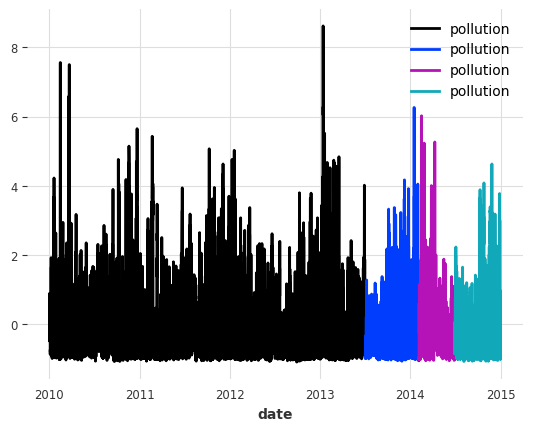

In [13]:
trainY, testY = Y.split_after(0.7)
testY, valY = testY.split_after(0.66)
testY, testY2 = testY.split_after(0.6)


print(len(trainY))
print(len(testY))
print(len(testY2))
print(len(valY))

trainY.plot()
testY.plot()
testY2.plot()
valY.plot()

In [14]:
futuros=23

In [15]:
import pytorch_lightning as pl

# Fijar la semilla para la reproducibilidad
pl.seed_everything(42)

INFO:lightning_fabric.utilities.seed:Seed set to 42


42

In [16]:
import logging
log = logging.getLogger("pytorch_lightning")
log.propagate = False
log.setLevel(logging.ERROR)

In [17]:
from pytorch_lightning.callbacks import Callback

class LossRecorder(Callback):
    def __init__(self):
        self.train_loss_history = []
        self.val_loss_history = []

    def on_train_epoch_end(self, trainer, pl_module):
        self.train_loss_history.append(trainer.callback_metrics["train_loss"].item())
        self.val_loss_history.append(trainer.callback_metrics["val_loss"].item())

In [ ]:
params = {'batch_size': 8, 'dropout': 0.3, 'hidden_continuous_size': 128, 'hidden_size': 32, 'learning_rate': 0.0027779340280557735, 'lstm_layers': 3.0, 'num_attention_heads': 8}


early_stopper = pl.callbacks.EarlyStopping(
monitor="val_loss",
patience=15,
min_delta=0,
mode='min',
verbose = True
)

loss_recorder = LossRecorder()

my_model = TFTModel(
    input_chunk_length=pasados,
    output_chunk_length=1,
    hidden_size=int(params["hidden_size"]),
    dropout=float(params["dropout"]),
    batch_size=int(params["batch_size"]),
    n_epochs=128,
    optimizer_kwargs={"lr": float(params["learning_rate"])},
    random_state=42,
    add_relative_index= True,
    loss_fn=torch.nn.MSELoss(),
    likelihood=None,
    output_chunk_shift = futuros,
    save_checkpoints = True,
    use_static_covariates = False,
    lstm_layers = int(params["lstm_layers"]),
    hidden_continuous_size = int(params["hidden_continuous_size"]),
    num_attention_heads = int(params["num_attention_heads"]),
    pl_trainer_kwargs= {"callbacks": [early_stopper, loss_recorder],
                        "accelerator": "gpu",  
                        "devices": "auto"}
)
my_model.fit(
    series=testY,
    val_series=testY2,
    past_covariates=testX,
    val_past_covariates=testX2,
    verbose=True
)
my_model = TFTModel.load_from_checkpoint(model_name=my_model.model_name, best=True)



Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/darts/models/forecasting/torch_forecasting_model.py:1842: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model: TorchForecastingModel 

In [ ]:
# Crear todas las ventanas de 12 pasos
windowed_target_series = [valY[i:i + 12] for i in range(0, len(valY) - 12)]
windowed_covariates_series = [valX[i:i + 12] for i in range(0, len(valX) - 12)]
batch_size = 32
all_predictions = []
# Dividimos las ventanas en lotes (batches)
for i in range(0, len(windowed_target_series), batch_size):
    batch_target_windows = windowed_target_series[i:i + batch_size]
    batch_covariates_windows = windowed_covariates_series[i:i + batch_size]

    # Hacer la predicción para este lote de ventanas
    predictions = my_model.predict(
        n=1,  # Predecir solo un valor futuro para cada ventana
        series=batch_target_windows,  # Ventanas de la serie target
        past_covariates=batch_covariates_windows,  # Ventanas de las covariantes
        batch_size=batch_size,  # Tamaño del batch
        verbose=False
    )
    for pred in predictions:
        all_predictions.extend(pred.values())

preds = np.array(all_predictions)


trues = np.array(valY[pasados+futuros:].values())
if len(trues) > len(preds):
  trues = trues[:len(preds)]
else:
    preds = preds[:len(trues)]


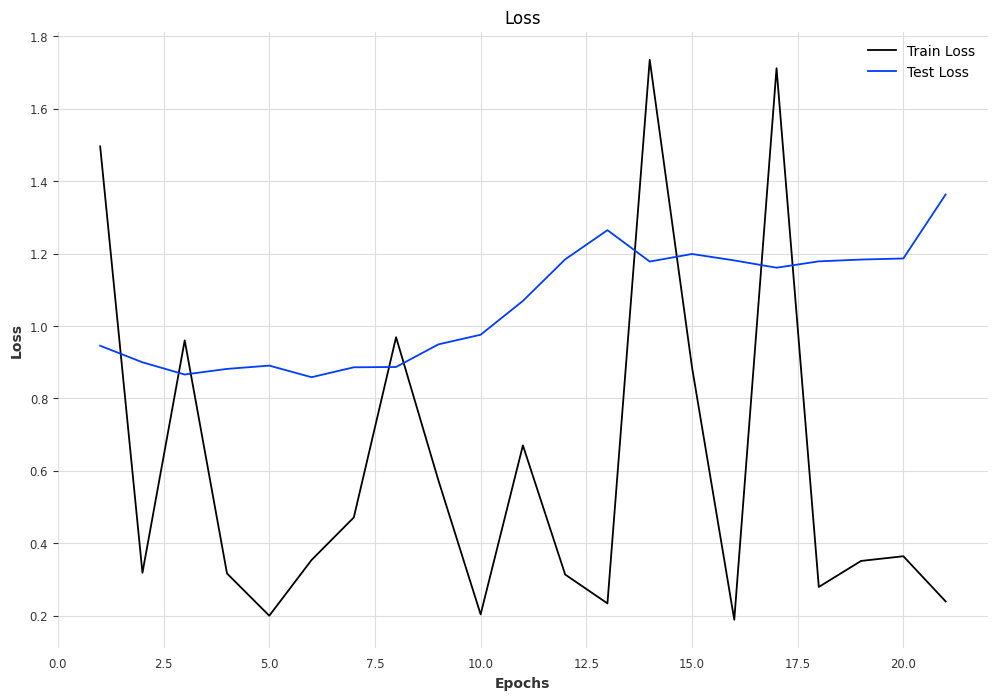

In [20]:
ejeXTFT = range(1, len(loss_recorder.train_loss_history) + 1)
plt.figure(figsize=(12, 8))
plt.plot(ejeXTFT, loss_recorder.train_loss_history, label='Train Loss')
plt.plot(ejeXTFT, loss_recorder.val_loss_history, label='Test Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [21]:
from sklearn.metrics import mean_absolute_error

def smape(y_true, y_pred):
    summ = np.abs(y_true) + np.abs(y_pred)
    smape_val = np.abs(y_pred - y_true) / summ * 2.0
    return np.mean(smape_val)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

def ia(y_true, y_pred):
    numerator = np.sum(np.abs(y_true - y_pred))
    denominator = np.sum(np.abs(y_true - np.mean(y_true)) + np.abs(y_pred - np.mean(y_true)))
    return 1 - (numerator / denominator)

In [22]:
# Calcular MSE
mse = mean_squared_error(trues, preds)

# Calcular RMSE
rmse_value = rmse(trues, preds)

# Calcular MAE
mae = mean_absolute_error(trues, preds)

smape_value = smape(trues, preds)

ia_value = ia(trues, preds)


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.7894130980506091
RMSE: 0.8884892222478611
MAE: 0.6666524508071834
SMAPE: 1.1745564396566355
IA: 0.36378001303024654


In [23]:
from datetime import timedelta

# Fecha y hora de término del conjunto de datos de prueba
end_date = datosNormalizados.index[-1]
n_observations = len(valY)

# Calcular la fecha y hora de inicio
start_date = end_date - timedelta(hours=(n_observations - 1))

# Crear la serie de fechas y horas
val_date = pd.date_range(start=start_date, end=end_date, freq='H')

val_date = val_date[pasados+futuros:]

<ipython-input-23-f202fb545567>:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  val_date = pd.date_range(start=start_date, end=end_date, freq='H')


In [24]:
print(len(valY))

4468


In [25]:
datosNormalizados.tail(2)

,pollution,dew,temp,press,wnd_dir,wnd_spd,error
date,,,,,,,
2014-12-31 22:00:00,-1.009952,-1.632347,-1.268524,1.679851,0.694538,4.344399,-0.546288
2014-12-31 23:00:00,-0.966063,-1.562627,-1.187734,1.679851,0.694538,4.405847,-0.482464


In [ ]:
import plotly.express as px
import plotly.graph_objects as go

# Crea un DataFrame con los datos originales y los predichos
df = pd.DataFrame({'Originales': trues.flatten(), 'Predichos': preds.flatten()})
df.index = val_date

fecha_inicio = df.index[0]
fecha_fin = df.index[-1]


fig = px.line(df, title='Valores Originales vs Valores Predichos')
fig.update_xaxes(rangeslider_visible=True, title='Índice de la Muestra', range=[fecha_inicio, fecha_fin])
fig.update_yaxes(title='Valores')


fig.add_trace(go.Scatter(x=df.index, y=[0] * len(df), mode='lines', name='Igualdad', line=dict(color='black', dash='dash')))

fig.show()

In [27]:
df.to_csv("/content/drive/MyDrive/transformers/errores/narmax/24paso/tftPollution.csv", index=True)

In [28]:
model_save_path = '/content/drive/My Drive/transformers/modelosEntrenados/NARMAX/24_pollution_tft.pt'
my_model.save(model_save_path)